<a href="https://colab.research.google.com/github/Lok-Tung/Just-for-fun/blob/main/loan-portfolio-analysis/Loan_Portfolio_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression

In [13]:
# -------------------------
# 1. Generate Synthetic Loan Data
# -------------------------
def generate_loan_data(n_loans=2000, start_date='2020-01-01', end_date='2023-12-31'):
  np.random.seed(42)
  loan_ids = [f'LN{i:05d}' for i in range(1, n_loans+1)]
  start = pd.to_datetime(start_date)
  end = pd.to_datetime(end_date)
  date_range = (end - start).days
  issue_dates = [start + timedelta(days=np.random.randint(0, date_range)) for _ in range(n_loans)]


  df = pd.DataFrame({
  'loan_id': loan_ids,
  'issue_date': issue_dates,
  'loan_amount': np.random.lognormal(mean=9.5, sigma=0.5, size=n_loans).astype(int),
  'interest_rate': np.random.normal(loc=0.08, scale=0.02, size=n_loans),
  'term': np.random.choice([12, 24, 36, 60], size=n_loans, p=[0.1, 0.3, 0.4, 0.2]),
  'grade': np.random.choice(['A', 'B', 'C', 'D', 'E'], size=n_loans, p=[0.2, 0.3, 0.25, 0.15, 0.1]),
  'channel': np.random.choice(['Online', 'Partner', 'Branch'], size=n_loans, p=[0.6, 0.3, 0.1]),
  'dti': np.random.normal(loc=18, scale=8, size=n_loans),
  'annual_inc': np.random.lognormal(mean=10.8, sigma=0.4, size=n_loans).astype(int),
  'fico_score': np.random.normal(loc=680, scale=50, size=n_loans).astype(int)
  })


  df['interest_rate'] = df['interest_rate'].clip(0.04, 0.15)
  df['dti'] = df['dti'].clip(5, 35)
  df['fico_score'] = df['fico_score'].clip(600, 800)
  df['annual_inc'] = df['annual_inc'].clip(30000, 200000)
  df['vintage'] = df['issue_date'].dt.to_period('M')


  df['prob_default'] = 1 / (1 + np.exp(-0.1 * (df['fico_score'] - 700)))
  df['loan_status'] = np.where(
  df['prob_default'] > np.random.random(size=n_loans), 'Default', 'Current'
  )


  older_loans = df[df['issue_date'] < pd.to_datetime('2022-01-01')].index
  df.loc[older_loans, 'loan_status'] = np.random.choice(
  ['Fully Paid', 'Current', 'Default'], size=len(older_loans), p=[0.6, 0.3, 0.1]
  )
  return df


loan_df = generate_loan_data()

In [15]:
# -------------------------
# 2. Loan Pricing Optimization
# -------------------------
def calculate_expected_profit(df, rate_shift=0.0):
  df = df.copy()
  df["adj_rate"] = df["interest_rate"] + rate_shift
  df["interest_income"] = df["loan_amount"] * df["adj_rate"] * (df["term"] / 12)
  df["expected_loss"] = df["loan_amount"] * df["prob_default"]
  df["net_profit"] = df["interest_income"] - df["expected_loss"]
  roa = df["net_profit"].sum() / df["loan_amount"].sum()
  return roa, df


for shift in [-0.02, -0.01, 0, 0.01, 0.02]:
  roa, _ = calculate_expected_profit(loan_df, rate_shift=shift)
  print(f"Rate shift {shift:+.2%} → Expected ROA: {roa:.2%}")

Rate shift -2.00% → Expected ROA: -19.93%
Rate shift -1.00% → Expected ROA: -17.08%
Rate shift +0.00% → Expected ROA: -14.22%
Rate shift +1.00% → Expected ROA: -11.36%
Rate shift +2.00% → Expected ROA: -8.50%


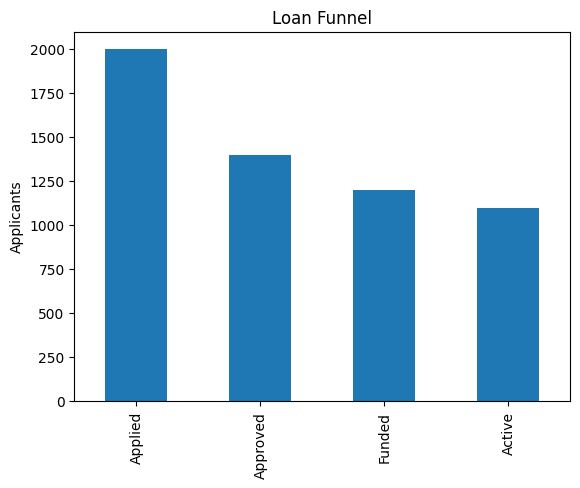

In [16]:
# -------------------------
# 3. Funnel Analytics
# -------------------------
def simulate_funnel(df):
  np.random.seed(42)
  stages = {
  "Applied": len(df),
  "Approved": int(len(df) * 0.7),
  "Funded": int(len(df) * 0.6),
  "Active": int(len(df) * 0.55)
  }
  return pd.Series(stages, name="count")


funnel = simulate_funnel(loan_df)
funnel.plot(kind="bar", title="Loan Funnel", ylabel="Applicants")
plt.show()

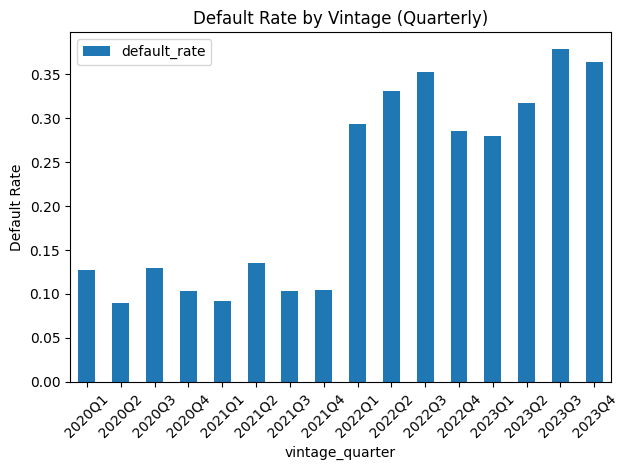

In [43]:
# -------------------------
# 4. Vintage Analysis
# -------------------------
loan_df['vintage_quarter'] = loan_df['issue_date'].dt.to_period('Q')
vintage_performance = loan_df.groupby('vintage_quarter').agg({
    'loan_status': lambda x: (x == 'Default').sum() / len(x)
}).rename(columns={'loan_status': 'default_rate'})

vintage_performance.plot(kind='bar', title='Default Rate by Vintage (Quarterly)')
plt.xticks(rotation=45)
plt.ylabel('Default Rate')
plt.tight_layout()
plt.show()

In [20]:
# -------------------------
# 5. Elasticity Modeling
# -------------------------
features = ["interest_rate", "fico_score", "dti"]
X = loan_df[features]
y = (loan_df["loan_status"] == "Default").astype(int)


logit = LogisticRegression(max_iter=1000)
logit.fit(X, y)
coeffs = pd.Series(logit.coef_[0], index=features)
print("Elasticity Coefficients:\n", coeffs)

Elasticity Coefficients:
 interest_rate   -0.150758
fico_score       0.025606
dti              0.005876
dtype: float64


In [21]:
# -------------------------
# 6. Default Prediction (Agentic Analytics)
# -------------------------
X = loan_df[["loan_amount", "interest_rate", "fico_score", "dti", "annual_inc"]]
y = (loan_df["loan_status"] == "Default").astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
preds = rf.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, preds))

ROC-AUC: 0.8251436943536572


In [26]:
# -------------------------
# 7. Portfolio Dashboard
# -------------------------
summary = {
    "Total Loans": f"{len(loan_df):,}",
    "Total Volume": f"${loan_df['loan_amount'].sum():,}",
    "Default Rate": f"{(loan_df['loan_status']=='Default').mean():.2%}",
    "Average Interest Rate": f"{loan_df['interest_rate'].mean():.2%}",
    "Average FICO": round(loan_df['fico_score'].mean(), 0)
}
print(pd.Series(summary).to_frame("Portfolio Summary"))


                      Portfolio Summary
Total Loans                       2,000
Total Volume                $29,836,023
Default Rate                     22.50%
Average Interest Rate             8.00%
Average FICO                      680.0
